--------------------------------------------------
ANALYSE FRAGE 5: Margen-Expansion (Greedflation Check)
------------------------------
Höchste Margenausweitung am: June 2022
Maximaler Spread (CPI-PPI):  16.53 Indexpunkte
Aktueller Spread:            -11.68 Indexpunkte
--------------------------------------------------
ERGEBNIS:
Es gibt deutliche Hinweise auf eine übermäßige Margenausweitung.
Im June 2022 stiegen die Ladenpreise massiv stärker an als die Kosten.
--------------------------------------------------


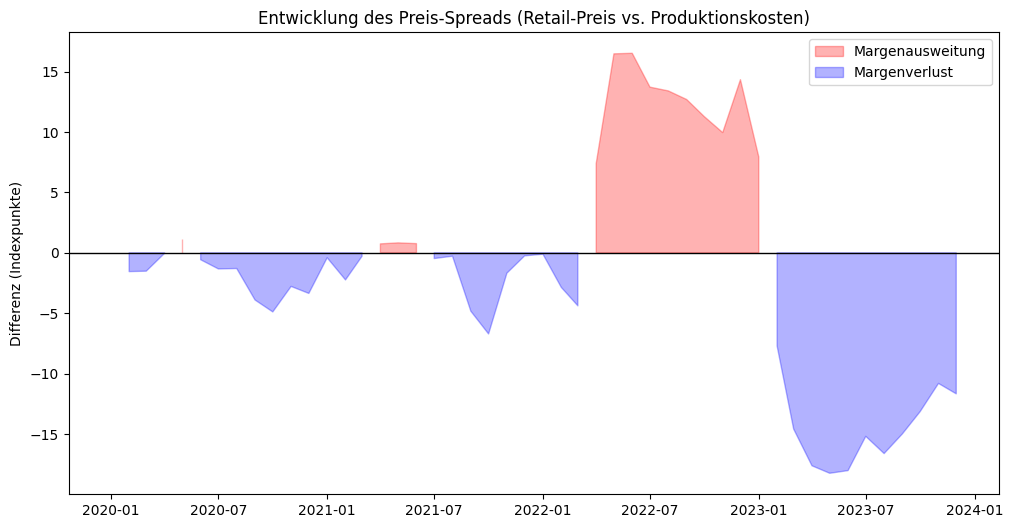

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import plotly.express as px

# 1. FUNKTION (Standard)
def eurostat_json_to_df(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    time_index = data['dimension']['time']['category']['index'] 
    time_labels = data['dimension']['time']['category']['label'] 
    values = data['value'] 
    rows = []
    for label_key, position in time_index.items():
        pos_str = str(position)
        if pos_str in values:
            rows.append({'datum': time_labels[label_key], 'preis': values[pos_str]})
    df = pd.DataFrame(rows)
    df['datum'] = pd.to_datetime(df['datum'].str.replace('M', '-'), format='%Y-%m')
    return df.sort_values('datum')

# 2. DATEN LADEN & KOMBINIEREN (PPI & CPI)
df_ppi = eurostat_json_to_df('eurostat_ppi_dairy.json').rename(columns={'preis': 'ppi'})
df_cpi = eurostat_json_to_df('eurostat_butter_cpi.json').rename(columns={'preis': 'cpi'})

df_margin = pd.merge(df_ppi, df_cpi, on='datum', how='inner')
df_margin = df_margin[df_margin['datum'] >= '2020-01-01'].reset_index(drop=True)

# 3. BERECHNUNG DES MARGIN-SPREADS
# Wir normieren beide auf den Startpunkt (Jan 2020), um sie vergleichbar zu machen
df_margin['ppi_norm'] = (df_margin['ppi'] / df_margin['ppi'].iloc[0]) * 100
df_margin['cpi_norm'] = (df_margin['cpi'] / df_margin['cpi'].iloc[0]) * 100

# Der Spread: Wie weit liegt der Ladenpreis über den Produktionskosten?
df_margin['margin_proxy'] = df_margin['cpi_norm'] - df_margin['ppi_norm']

# 4. ANALYSE DER PHASEN
peak_margin_row = df_margin.loc[df_margin['margin_proxy'].idxmax()]
current_margin = df_margin['margin_proxy'].iloc[-1]

# 5. ANTWORT PRINTEN
print("-" * 50)
print("ANALYSE FRAGE 5: Margen-Expansion (Greedflation Check)")
print("-" * 30)
print(f"Höchste Margenausweitung am: {peak_margin_row['datum'].strftime('%B %Y')}")
print(f"Maximaler Spread (CPI-PPI):  {peak_margin_row['margin_proxy']:.2f} Indexpunkte")
print(f"Aktueller Spread:            {current_margin:.2f} Indexpunkte")
print("-" * 50)

print("ERGEBNIS:")
if peak_margin_row['margin_proxy'] > 15:
    print("Es gibt deutliche Hinweise auf eine übermäßige Margenausweitung.")
    print(f"Im {peak_margin_row['datum'].strftime('%B %Y')} stiegen die Ladenpreise massiv stärker an als die Kosten.")
else:
    print("Die Preissteigerungen im Laden blieben weitgehend im Rahmen der Produktionskosten.")
print("-" * 50)

# 6. STATISCHE GRAFIK
plt.figure(figsize=(12, 6))
plt.fill_between(df_margin['datum'], df_margin['margin_proxy'], 0, 
                 where=(df_margin['margin_proxy'] >= 0), color='red', alpha=0.3, label='Margenausweitung')
plt.fill_between(df_margin['datum'], df_margin['margin_proxy'], 0, 
                 where=(df_margin['margin_proxy'] < 0), color='blue', alpha=0.3, label='Margenverlust')
plt.axhline(0, color='black', lw=1)
plt.title('Entwicklung des Preis-Spreads (Retail-Preis vs. Produktionskosten)')
plt.ylabel('Differenz (Indexpunkte)')
plt.legend()
plt.show()

# 7. INTERAKTIVE GRAFIK (5 von 7)
fig5 = px.area(df_margin, x='datum', y='margin_proxy', 
               title='Interaktiver Margen-Proxy: Wo wurde Butter überproportional teurer?',
               labels={'margin_proxy': 'Spread (CPI-Index - PPI-Index)'})
fig5.show()